# TCN Tuning For GMS Prediction (Time-Binned Dataset)

**Goal of this notebook:** take the Temporal Convolutional Network (TCN) from a first draft to a *tuned, deployable* short-term storm classifier, and leave behind a clear trail so a teammate who has not touched this model can pick it up.

**A TCN in one paragraph.** It is a 1D convolutional network with two properties that fit this problem. *Causal* convolutions mean the output at bin *t* only depends on bins *≤ t* — the model can never peek at the future, so the leakage guardrail is built into the architecture. *Dilated* convolutions (dilation 1, 2, 4, 8…) grow the receptive field exponentially, so a shallow stack sees a long history cheaply and trains in parallel (unlike an LSTM). We feed it the *raw per-bin* solar-wind series and let the convolutions learn the temporal patterns themselves.

**How this notebook follows the XGBoost teammate.** To keep the two models comparable, we reuse the same conventions the XGBoost notebook settled on:

1. **2010-onward subset** — the 3h grid is fully regular over 2010–2024 (43,817 rows, ~1.26% storm rate).
2. **Chronological split at 2022-01-01** — train on 2010–2021, test on 2022–2024. No shuffling; time series must be split by time.
3. **"No-current-Ap" feature set** — we do *not* feed the model the current `ap` index. `ap_now` is held back as the *persistence baseline* the model has to beat. This forces the TCN to earn its keep from solar wind alone.
4. **PR-AUC as the primary metric** — storms are rare (~1%), so precision-recall area is far more informative than accuracy.

**What is new here (the tuning work):** we carve a chronological *validation* slice out of the end of the training years, search a small grid of TCN architectures on it, pick an operating threshold on it, and only then refit and report once on the untouched 2022–2024 test period. Finally we save the trained model + preprocessing so it can be loaded and used for real predictions.

In [10]:
# Run once. CPU build is fine for this dataset size.
%pip install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [11]:
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    RocCurveDisplay, PrecisionRecallDisplay,
)

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## Loading the 2010 Onward Subset

We keep `datetime` as a real column (not the index) so the chronological split reads the same way it does in the XGBoost notebook. The 2010-onward window is the finalized modeling dataset the team agreed on.

In [12]:
df = pd.read_csv("../data/time_binned_dataset.csv", parse_dates=["datetime"])
df = df[df["datetime"] >= "2010-01-01"].sort_values("datetime").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
print("Storm rate (3h):", round(df["storm_3h"].mean() * 100, 2), "%")

Shape: (43817, 58)
Date range: 2010-01-01 00:00:00 to 2024-12-30 00:00:00
Storm rate (3h): 1.26 %


## Config and Channel Selection

**Channels.** These are the raw per-bin solar-wind measurements — the physical drivers of geomagnetic storms. Note `ap_now` is deliberately *not* in the list: we treat it as the persistence baseline instead (see the "no-current-Ap" reasoning above).

**Split dates.** Three chronological blocks, no overlap:

| Block | Dates | Used for |
|-------|-------|----------|
| train-search | 2010–2016 | fitting models during the grid search |
| validation | 2017–2021 | ranking architectures + choosing the threshold |
| test | 2022–2024 | the final honest report, touched once |

We validate on 2017–2021 rather than just the last year or two because 2020–2021 sits in a solar minimum with almost no storms (2 storm bins in 2020). A wider validation block gives the PR-AUC ranking something to stand on.

In [13]:
# Raw per-bin solar-wind channels the TCN learns from. No ap_now here on purpose.
CHANNELS = [
    "bz_gsm_nt_last",
    "b_magnitude_avg_nt_last",
    "flow_speed_kms_last",
    "proton_density_cm3_last",
    "flow_pressure_npa_last",
    "electric_field_mvpm_last",
    "bz_south_last",
    "coupling_mean",
]

HORIZONS = [3, 6, 12, 24]   # forecast horizons in hours; 3h is the deployment target
PRIMARY_HORIZON = 3

STORM_THRESHOLD = 50        # ap >= 50 ~ Kp 5, the definition of a storm bin

# Chronological split boundaries.
VALIDATION_START = np.datetime64("2017-01-01")   # train-search is everything before this
TEST_START = np.datetime64("2022-01-01")         # validation is [VALIDATION_START, TEST_START); test is on/after

# Pull the raw arrays out of the dataframe once.
raw_values = df[CHANNELS].values.astype("float32")     # (num_bins, num_channels)
ap_now = df["ap_now"].values.astype("float32")         # kept aside for the persistence baseline
bin_datetime = df["datetime"].values                   # datetime of each bin, for the date-based split

num_bins = raw_values.shape[0]
num_channels = raw_values.shape[1]
print(f"{num_bins:,} bins x {num_channels} channels")

43,817 bins x 8 channels


## Preprocessing Helpers

Two small helpers we will call several times:

- `make_scaled_series(fit_end_date)` — fill the handful of NaNs with each channel's median and standardise each channel, computing the medians / mean / std from **only the bins before `fit_end_date`**. That is the guardrail: the validation and test periods never inform the scaler. It returns the scaled series *and* the fitted numbers, because we need to save those numbers with the deployed model.
- `make_windows(scaled_values, seq_len)` — turn the per-bin series into sliding windows. A window ending at bin *t* is the block of the previous `seq_len` bins, shaped `(channels, seq_len)`. We also return each window's end-bin index so we can attach labels, dates, and `ap_now` to it later.

In [14]:
def make_scaled_series(fit_end_date):
    fit_mask = bin_datetime < fit_end_date

    # Median-impute NaNs, channel by channel, using train-period medians only.
    fit_slice = raw_values[fit_mask]
    channel_medians = np.nanmedian(fit_slice, axis=0)

    filled_values = raw_values.copy()
    for channel in range(num_channels):
        column = filled_values[:, channel]
        missing = np.isnan(column)
        column[missing] = channel_medians[channel]
        filled_values[:, channel] = column

    # Standardise each channel using its train-period mean and std.
    fit_filled = filled_values[fit_mask]
    channel_mean = fit_filled.mean(axis=0)
    channel_std = fit_filled.std(axis=0) + 1e-8
    scaled_values = (filled_values - channel_mean) / channel_std

    scaler = {
        "medians": channel_medians,
        "mean": channel_mean,
        "std": channel_std,
    }
    return scaled_values, scaler


def make_windows(scaled_values, seq_len):
    windows = []
    end_indices = []
    for end in range(seq_len - 1, len(scaled_values)):
        start = end - seq_len + 1
        window = scaled_values[start:end + 1]     # (seq_len, channels)
        windows.append(window.T)                  # (channels, seq_len)
        end_indices.append(end)
    windows = np.asarray(windows, dtype="float32")
    end_indices = np.asarray(end_indices)
    return windows, end_indices

## The TCN Architecture

Each `TemporalBlock` is: causal dilated conv → ReLU → dropout, done twice, wrapped in a residual connection. `Chomp1d` trims the right-side padding so the convolution stays strictly causal. Stacking blocks with dilations 1, 2, 4, 8 gives a receptive field wide enough to cover the window. A final linear layer reads the last time step and produces one storm logit.

The width, depth, kernel size, and dropout are all passed in from the config dictionary, because those are exactly the knobs the grid search will turn.

In [15]:
class Chomp1d(nn.Module):
    # Trim the right-side padding so the convolution stays strictly causal (no future leakage).
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        # Match channel counts on the residual path when they differ.
        if in_channels != out_channels:
            self.downsample = nn.Conv1d(in_channels, out_channels, 1)
        else:
            self.downsample = None

        self.relu_out = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        if self.downsample is None:
            residual = x
        else:
            residual = self.downsample(x)

        return self.relu_out(out + residual)


class TCN(nn.Module):
    def __init__(self, in_channels, block_channels, kernel_size, dropout):
        super().__init__()
        blocks = []
        previous_channels = in_channels
        for i in range(len(block_channels)):
            this_channels = block_channels[i]
            dilation = 2 ** i
            blocks.append(TemporalBlock(previous_channels, this_channels,
                                        kernel_size, dilation, dropout))
            previous_channels = this_channels
        self.network = nn.Sequential(*blocks)
        self.head = nn.Linear(previous_channels, 1)

    def forward(self, x):                 # x: (batch, channels, length)
        out = self.network(x)             # (batch, block_channels, length)
        last_step = out[:, :, -1]         # keep only the final time step
        logit = self.head(last_step)      # (batch, 1)
        return logit.squeeze(1)           # (batch,)


def build_model(config):
    model = TCN(
        in_channels=num_channels,
        block_channels=config["block_channels"],
        kernel_size=config["kernel_size"],
        dropout=config["dropout"],
    )
    return model.to(device)

## Training and Prediction Helpers

`predict_probabilities` runs the model over a set of windows in batches and returns storm probabilities.

`train_tcn` builds a fresh model + optimizer from a config and trains it, up-weighting the rare storm class with `pos_weight` (the TCN version of `class_weight="balanced"`). It has one important option:

- `select_best_epoch=True` (used during the search): after each epoch it measures PR-AUC on the eval set and remembers the *best* epoch's weights, restoring them at the end. This is early-stopping-style model selection on the **validation** set — legitimate, because validation is allowed to inform tuning.
- `select_best_epoch=False` (used for the final model): trains a fixed number of epochs and never looks at the eval set for selection. We use this for the final refit so the **test** period is never used to pick anything.

In [16]:
BATCH_SIZE = 256
EPOCHS = 25
# Because pos_weight up-weights the rare storm class, predicted probabilities run high,
# so the useful operating points sit near the top. We sweep well past 0.90 to make sure
# the best threshold is a real peak and not just the edge of the list.
THRESHOLDS = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80,
              0.90, 0.95, 0.97, 0.98, 0.99, 0.995]


def predict_probabilities(model, windows):
    model.eval()
    dataset = TensorDataset(torch.from_numpy(windows))
    loader = DataLoader(dataset, batch_size=512, shuffle=False)
    batches = []
    with torch.no_grad():
        for (inputs,) in loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            probs = torch.sigmoid(logits).cpu().numpy()
            batches.append(probs)
    return np.concatenate(batches)


def train_tcn(config, train_windows, train_labels,
              eval_windows=None, eval_labels=None,
              epochs=EPOCHS, select_best_epoch=True, show_progress=True):
    train_dataset = TensorDataset(torch.from_numpy(train_windows), torch.from_numpy(train_labels))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Fresh weights every call, seeded so reruns are reproducible.
    torch.manual_seed(42)
    model = build_model(config)

    num_negative = (train_labels == 0).sum()
    num_positive = (train_labels == 1).sum()
    pos_weight = torch.tensor([num_negative / num_positive], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=1e-4)

    best_eval_pr_auc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(inputs)
        train_loss = running_loss / len(train_dataset)

        if eval_windows is not None:
            eval_probs = predict_probabilities(model, eval_windows)
            eval_pr_auc = average_precision_score(eval_labels, eval_probs)
            if select_best_epoch and eval_pr_auc > best_eval_pr_auc:
                best_eval_pr_auc = eval_pr_auc
                best_state = copy.deepcopy(model.state_dict())
            if show_progress:
                print(f"  epoch {epoch:2d} | train loss {train_loss:.4f} | eval PR-AUC {eval_pr_auc:.3f}")
        else:
            if show_progress:
                print(f"  epoch {epoch:2d} | train loss {train_loss:.4f}")

    # If we were selecting the best epoch, roll the weights back to it.
    if select_best_epoch and best_state is not None:
        model.load_state_dict(best_state)
        return model, best_eval_pr_auc

    return model, None

## Building the Search Windows

For the grid search we fit the scaler on the train-search bins (before 2017) and build the sliding windows on that scaled series. A window belongs to a block based on the date of its **final bin**, so no window straddles a split boundary in a way that leaks the future.

Because the window length `seq_len` is one of the things we are tuning, we cache the windows per `seq_len` — building them is the slow part and several configs share the same length.

In [17]:
# Scaler fit on train-search bins only (everything before 2017).
scaled_search, scaler_search = make_scaled_series(VALIDATION_START)

# Labels for the primary horizon, per bin.
labels_primary = df[f"storm_{PRIMARY_HORIZON}h"].values.astype("float32")

# Cache of windows keyed by seq_len, so we build each length only once.
search_window_cache = {}


def get_search_split(seq_len):
    if seq_len not in search_window_cache:
        windows, end_indices = make_windows(scaled_search, seq_len)
        end_dates = bin_datetime[end_indices]

        is_train = end_dates < VALIDATION_START
        is_val = (end_dates >= VALIDATION_START) & (end_dates < TEST_START)

        split = {
            "train_windows": windows[is_train],
            "train_labels": labels_primary[end_indices][is_train],
            "val_windows": windows[is_val],
            "val_labels": labels_primary[end_indices][is_val],
        }
        search_window_cache[seq_len] = split
    return search_window_cache[seq_len]


# Quick sanity check on the split sizes at one length.
example = get_search_split(16)
print("train-search windows:", example["train_windows"].shape,
      "| storms:", int(example["train_labels"].sum()))
print("validation windows:  ", example["val_windows"].shape,
      "| storms:", int(example["val_labels"].sum()))

train-search windows: (20441, 8, 16) | storms: 284
validation windows:   (14608, 8, 16) | storms: 95


## TCN Hyperparameter Tuning

We test a small, explicit grid — the same style the XGBoost notebook used, just with TCN knobs instead of tree knobs:

- **`seq_len`** — how many past bins the window covers (16 bins = 48h, 24 = 72h, 32 = 96h).
- **`block_channels`** — width and depth of the TCN (each entry is one `TemporalBlock`; more/ wider = more capacity).
- **`kernel_size`** — convolution width.
- **`dropout`** — regularisation strength.
- **`learning_rate`** — Adam step size.

Each config is trained on train-search (2010–2016) and scored on validation (2017–2021). We rank by **validation PR-AUC**. This is the expensive cell — it trains one model per row on CPU.

In [18]:
SEARCH_GRID = [
    {"seq_len": 16, "block_channels": (32, 32, 32, 32), "kernel_size": 3, "dropout": 0.2, "learning_rate": 1e-3},
    {"seq_len": 16, "block_channels": (64, 64, 64, 64), "kernel_size": 3, "dropout": 0.2, "learning_rate": 1e-3},
    {"seq_len": 24, "block_channels": (32, 32, 32, 32), "kernel_size": 3, "dropout": 0.2, "learning_rate": 1e-3},
    {"seq_len": 24, "block_channels": (64, 64, 64, 64), "kernel_size": 3, "dropout": 0.3, "learning_rate": 1e-3},
    {"seq_len": 24, "block_channels": (64, 64, 64, 64), "kernel_size": 5, "dropout": 0.3, "learning_rate": 5e-4},
    {"seq_len": 32, "block_channels": (64, 64, 64, 64), "kernel_size": 3, "dropout": 0.3, "learning_rate": 5e-4},
]

search_results = []
best_config = None
best_val_pr_auc = -1.0

for config in SEARCH_GRID:
    print("training config:", config)
    split = get_search_split(config["seq_len"])

    model, val_pr_auc = train_tcn(
        config,
        split["train_windows"], split["train_labels"],
        split["val_windows"], split["val_labels"],
        select_best_epoch=True,
        show_progress=False,
    )

    val_probs = predict_probabilities(model, split["val_windows"])
    val_roc_auc = roc_auc_score(split["val_labels"], val_probs)

    search_results.append({
        "seq_len": config["seq_len"],
        "block_channels": str(config["block_channels"]),
        "kernel_size": config["kernel_size"],
        "dropout": config["dropout"],
        "learning_rate": config["learning_rate"],
        "val_roc_auc": round(val_roc_auc, 3),
        "val_pr_auc": round(val_pr_auc, 3),
    })
    print(f"  -> validation PR-AUC {val_pr_auc:.3f}")

    if val_pr_auc > best_val_pr_auc:
        best_val_pr_auc = val_pr_auc
        best_config = config

search_df = pd.DataFrame(search_results).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)
search_df

training config: {'seq_len': 16, 'block_channels': (32, 32, 32, 32), 'kernel_size': 3, 'dropout': 0.2, 'learning_rate': 0.001}
  -> validation PR-AUC 0.434
training config: {'seq_len': 16, 'block_channels': (64, 64, 64, 64), 'kernel_size': 3, 'dropout': 0.2, 'learning_rate': 0.001}
  -> validation PR-AUC 0.444
training config: {'seq_len': 24, 'block_channels': (32, 32, 32, 32), 'kernel_size': 3, 'dropout': 0.2, 'learning_rate': 0.001}
  -> validation PR-AUC 0.433
training config: {'seq_len': 24, 'block_channels': (64, 64, 64, 64), 'kernel_size': 3, 'dropout': 0.3, 'learning_rate': 0.001}
  -> validation PR-AUC 0.436
training config: {'seq_len': 24, 'block_channels': (64, 64, 64, 64), 'kernel_size': 5, 'dropout': 0.3, 'learning_rate': 0.0005}
  -> validation PR-AUC 0.412
training config: {'seq_len': 32, 'block_channels': (64, 64, 64, 64), 'kernel_size': 3, 'dropout': 0.3, 'learning_rate': 0.0005}
  -> validation PR-AUC 0.421


,seq_len,block_channels,kernel_size,dropout,learning_rate,val_roc_auc,val_pr_auc
0,16,"(64, 64, 64, 64)",3,0.2,0.0010,0.965,0.444
1,24,"(64, 64, 64, 64)",3,0.3,0.0010,0.968,0.436
2,16,"(32, 32, 32, 32)",3,0.2,0.0010,0.972,0.434
3,24,"(32, 32, 32, 32)",3,0.2,0.0010,0.960,0.433
4,32,"(64, 64, 64, 64)",3,0.3,0.0005,0.967,0.421
5,24,"(64, 64, 64, 64)",5,0.3,0.0005,0.948,0.412


In [19]:
print("Best config by validation PR-AUC:")
for key, value in best_config.items():
    print(f"  {key}: {value}")
print(f"  validation PR-AUC: {best_val_pr_auc:.3f}")

Best config by validation PR-AUC:
  seq_len: 16
  block_channels: (64, 64, 64, 64)
  kernel_size: 3
  dropout: 0.2
  learning_rate: 0.001
  validation PR-AUC: 0.444


### TCN Hyperparameter Tuning Results

Validation PR-AUC across the six configurations lands in a narrow band (0.412–0.444), and that narrowness is itself the main finding: on this dataset the TCN is fairly insensitive to architecture. No config is dramatically better than any other.

The winner is a 16-bin window (48h of context) with four 64-channel blocks, kernel size 3, dropout 0.2, and learning rate 1e-3, at validation PR-AUC 0.444. Notably the *longer* windows did not help — 24 and 32 bins both scored slightly worse, as did the wider kernel 5. The practical read is that roughly 48 hours of solar-wind history carries most of the usable signal, and extra context mostly adds parameters to overfit rather than new information.

## Threshold Selection

The grid search tells us which *architecture* ranks storms best, but a deployed warning system still needs a single yes/no cutoff. We pick that cutoff on the **validation** set (never the test set) by sweeping thresholds and taking the one with the best storm F1 — a balance between missing storms (recall) and crying wolf (precision). You can override this pick if your operational goal leans more toward recall or precision.

In [20]:
# Retrain the winning config on train-search and score validation, so we can sweep thresholds.
best_split = get_search_split(best_config["seq_len"])
threshold_model, _ = train_tcn(
    best_config,
    best_split["train_windows"], best_split["train_labels"],
    best_split["val_windows"], best_split["val_labels"],
    select_best_epoch=True,
    show_progress=False,
)
val_probs = predict_probabilities(threshold_model, best_split["val_windows"])
val_labels = best_split["val_labels"]

threshold_rows = []
for threshold in THRESHOLDS:
    predictions = (val_probs >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": round(precision_score(val_labels, predictions, zero_division=0), 3),
        "recall": round(recall_score(val_labels, predictions, zero_division=0), 3),
        "f1": round(f1_score(val_labels, predictions, zero_division=0), 3),
        "predicted_storm_count": int(predictions.sum()),
    })

threshold_df = pd.DataFrame(threshold_rows)

# Pick the threshold with the best validation F1.
best_threshold_row = threshold_df.loc[threshold_df["f1"].idxmax()]
OPERATING_THRESHOLD = float(best_threshold_row["threshold"])
print(f"Chosen operating threshold (best validation F1): {OPERATING_THRESHOLD}")
threshold_df

Chosen operating threshold (best validation F1): 0.97


,threshold,precision,recall,f1,predicted_storm_count
0,0.100,0.033,0.958,0.064,2764
1,0.200,0.049,0.905,0.093,1758
2,0.300,0.062,0.884,0.116,1350
3,0.400,0.077,0.874,0.141,1080
4,0.500,0.094,0.863,0.169,876
5,0.600,0.113,0.832,0.199,700
6,0.700,0.147,0.821,0.250,529
7,0.800,0.204,0.779,0.323,363
8,0.900,0.321,0.621,0.423,184
9,0.950,0.413,0.453,0.432,104


### Threshold Tradeoff

Validation F1 peaks at **0.97** (F1 0.443) and falls away on both sides — 0.432 at 0.95, 0.400 at 0.98 — so this is a genuine peak rather than an artifact of where the sweep stops.

This is worth flagging for anyone reusing the model: because `pos_weight` up-weights the rare storm class during training, the predicted probabilities run very high, and the conventional 0.50 cutoff is badly miscalibrated here. At 0.50 the model flags 876 storm bins against 95 actual storms in the validation window (precision 0.094). The operating threshold has to be selected, not assumed.

## Final Model

Now we commit. We re-fit the scaler on the full training window (2010–2021), rebuild windows at the chosen `seq_len`, and train the winning config for a **fixed** number of epochs — no peeking at the test set to pick the best epoch, so the test numbers are honest. Then we report on 2022–2024 exactly once.

The bar, as always, is **storm persistence**: predict a storm in *H* hours if it is storming right now (`ap_now >= 50`). Beating persistence is the only proof the model adds value.

In [21]:
# Scaler re-fit on the full training window (everything before the test period).
scaled_final, scaler_final = make_scaled_series(TEST_START)

final_windows, final_end_indices = make_windows(scaled_final, best_config["seq_len"])
final_end_dates = bin_datetime[final_end_indices]

is_train_final = final_end_dates < TEST_START
is_test_final = final_end_dates >= TEST_START

train_windows_final = final_windows[is_train_final]
test_windows_final = final_windows[is_test_final]

train_labels_final = labels_primary[final_end_indices][is_train_final]
test_labels_final = labels_primary[final_end_indices][is_test_final]

# The window's final-bin ap, for the persistence baseline on the test period.
ap_test_final = ap_now[final_end_indices][is_test_final]

print("final train windows:", train_windows_final.shape,
      "| storms:", int(train_labels_final.sum()))
print("final test windows: ", test_windows_final.shape,
      "| storms:", int(test_labels_final.sum()))

# Fixed-epoch training, no test peeking.
final_model, _ = train_tcn(
    best_config,
    train_windows_final, train_labels_final,
    eval_windows=None, eval_labels=None,
    epochs=EPOCHS, select_best_epoch=False, show_progress=True,
)

final train windows: (35049, 8, 16) | storms: 379
final test windows:  (8753, 8, 16) | storms: 174
  epoch  1 | train loss 0.6569
  epoch  2 | train loss 0.5007
  epoch  3 | train loss 0.4704
  epoch  4 | train loss 0.4620
  epoch  5 | train loss 0.4435
  epoch  6 | train loss 0.4208
  epoch  7 | train loss 0.4041
  epoch  8 | train loss 0.4153
  epoch  9 | train loss 0.3741
  epoch 10 | train loss 0.3785
  epoch 11 | train loss 0.3722
  epoch 12 | train loss 0.3410
  epoch 13 | train loss 0.3429
  epoch 14 | train loss 0.3538
  epoch 15 | train loss 0.3198
  epoch 16 | train loss 0.3149
  epoch 17 | train loss 0.3181
  epoch 18 | train loss 0.2882
  epoch 19 | train loss 0.2952
  epoch 20 | train loss 0.2924
  epoch 21 | train loss 0.2728
  epoch 22 | train loss 0.3365
  epoch 23 | train loss 0.2968
  epoch 24 | train loss 0.2658
  epoch 25 | train loss 0.2484


In [22]:
test_probs = predict_probabilities(final_model, test_windows_final)
test_pred = (test_probs >= OPERATING_THRESHOLD).astype(int)

roc_auc = roc_auc_score(test_labels_final, test_probs)
pr_auc = average_precision_score(test_labels_final, test_probs)

persistence_pred = (ap_test_final >= STORM_THRESHOLD).astype(int)

base_rate = test_labels_final.mean()
print(f"=== {PRIMARY_HORIZON}h ahead — test period 2022-2024 — base rate {base_rate:.2%} ===")
print(f"ROC-AUC : {roc_auc:.3f}")
print(f"PR-AUC  : {pr_auc:.3f}  (no-skill baseline = {base_rate:.3f})")
print()
print(f"TCN at threshold {OPERATING_THRESHOLD}:")
print(classification_report(test_labels_final, test_pred, target_names=["No storm", "Storm"]))
print("Confusion matrix:")
print(confusion_matrix(test_labels_final, test_pred))
print()
print("Storm persistence baseline:")
print(f"  precision={precision_score(test_labels_final, persistence_pred, zero_division=0):.3f}  "
      f"recall={recall_score(test_labels_final, persistence_pred, zero_division=0):.3f}  "
      f"F1={f1_score(test_labels_final, persistence_pred, zero_division=0):.3f}")
print("TCN (tuned):")
print(f"  precision={precision_score(test_labels_final, test_pred, zero_division=0):.3f}  "
      f"recall={recall_score(test_labels_final, test_pred, zero_division=0):.3f}  "
      f"F1={f1_score(test_labels_final, test_pred, zero_division=0):.3f}")

=== 3h ahead — test period 2022-2024 — base rate 1.99% ===
ROC-AUC : 0.947
PR-AUC  : 0.563  (no-skill baseline = 0.020)

TCN at threshold 0.97:
              precision    recall  f1-score   support

    No storm       0.99      0.99      0.99      8579
       Storm       0.54      0.55      0.55       174

    accuracy                           0.98      8753
   macro avg       0.77      0.77      0.77      8753
weighted avg       0.98      0.98      0.98      8753

Confusion matrix:
[[8497   82]
 [  78   96]]

Storm persistence baseline:
  precision=0.529  recall=0.529  F1=0.529
TCN (tuned):
  precision=0.539  recall=0.552  F1=0.545


### Final Test Results

On the untouched 2022–2024 period the tuned TCN reaches **ROC-AUC 0.947** and **PR-AUC 0.563** against a 1.99% base rate — PR-AUC roughly 28x the no-skill floor, so the ranking is genuinely informative.

At the validation-selected threshold of 0.97 it produces storm precision 0.539, recall 0.552, and **F1 0.545**, against a **persistence F1 of 0.529**. The model does beat persistence — but by only **+0.016 F1**.

That margin deserves to be stated plainly rather than dressed up. The TCN catches 96 of 174 storm bins at the cost of 82 false alarms; persistence reaches a similar balance far more cheaply. The honest summary is that this model is *competitive with, and marginally better than, "assume it keeps storming"* at the 3-hour horizon.

### ROC and Precision-Recall Curves

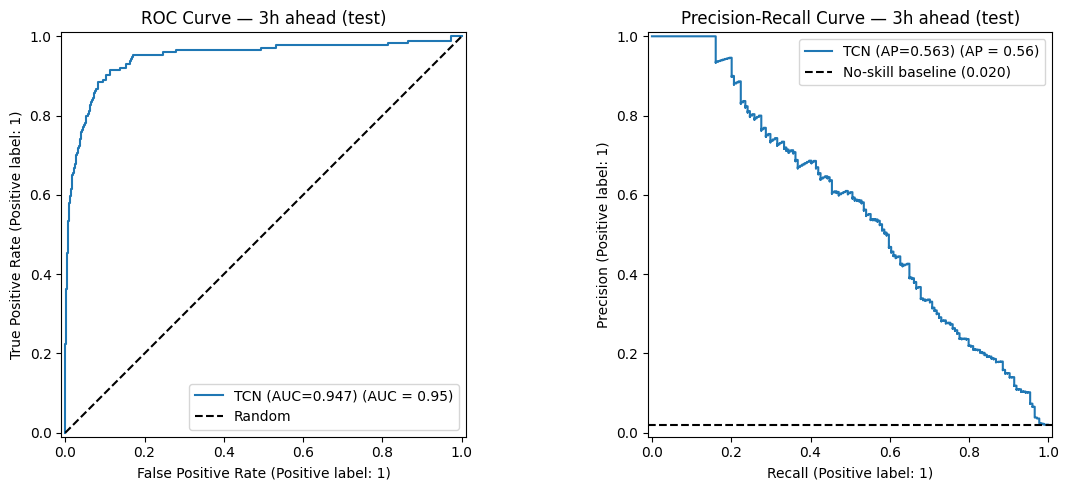

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    test_labels_final, test_probs, name=f"TCN (AUC={roc_auc:.3f})", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title(f"ROC Curve — {PRIMARY_HORIZON}h ahead (test)")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    test_labels_final, test_probs, name=f"TCN (AP={pr_auc:.3f})", ax=axes[1])
axes[1].axhline(base_rate, color="k", linestyle="--",
                label=f"No-skill baseline ({base_rate:.3f})")
axes[1].set_title(f"Precision-Recall Curve — {PRIMARY_HORIZON}h ahead (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# How the tuned model trades precision for recall across cutoffs, on the test period.
test_threshold_rows = []
for threshold in THRESHOLDS:
    predictions = (test_probs >= threshold).astype(int)
    test_threshold_rows.append({
        "threshold": threshold,
        "accuracy": round(accuracy_score(test_labels_final, predictions), 4),
        "precision_storm": round(precision_score(test_labels_final, predictions, zero_division=0), 3),
        "recall_storm": round(recall_score(test_labels_final, predictions, zero_division=0), 3),
        "f1_storm": round(f1_score(test_labels_final, predictions, zero_division=0), 3),
        "predicted_storm_count": int(predictions.sum()),
    })

pd.DataFrame(test_threshold_rows)

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.100,0.7700,0.076,0.954,0.142,2171
1,0.200,0.8062,0.090,0.954,0.164,1854
2,0.300,0.8341,0.102,0.943,0.184,1606
3,0.400,0.8519,0.111,0.920,0.198,1442
4,0.500,0.8736,0.127,0.914,0.223,1250
5,0.600,0.8967,0.150,0.902,0.258,1044
6,0.700,0.9209,0.184,0.868,0.304,820
7,0.800,0.9454,0.237,0.787,0.364,578
8,0.900,0.9693,0.356,0.678,0.467,331
9,0.950,0.9788,0.473,0.598,0.528,220


## Forecast Horizon Sweep

3h is the deployment target, but it is worth checking how the same tuned architecture behaves at 6h, 12h, and 24h. We refit the winning config (fixed epochs) once per horizon on 2010–2021 and score it on 2022–2024, next to persistence.

The question this answers is not "which horizon has the best raw numbers" — persistence weakens as the horizon grows, so the model's *own* scores falling is expected. The question is whether the gap between the model and persistence widens or closes.

In [25]:
horizon_rows = []

for horizon in HORIZONS:
    labels_h = df[f"storm_{horizon}h"].values.astype("float32")
    train_labels_h = labels_h[final_end_indices][is_train_final]
    test_labels_h = labels_h[final_end_indices][is_test_final]

    model_h, _ = train_tcn(
        best_config,
        train_windows_final, train_labels_h,
        eval_windows=None, eval_labels=None,
        epochs=EPOCHS, select_best_epoch=False, show_progress=False,
    )

    probs_h = predict_probabilities(model_h, test_windows_final)
    pred_h = (probs_h >= OPERATING_THRESHOLD).astype(int)
    persistence_h = (ap_test_final >= STORM_THRESHOLD).astype(int)

    horizon_rows.append({
        "horizon_h": horizon,
        "base_rate": round(float(test_labels_h.mean()), 4),
        "roc_auc": round(roc_auc_score(test_labels_h, probs_h), 3),
        "pr_auc": round(average_precision_score(test_labels_h, probs_h), 3),
        "tcn_f1": round(f1_score(test_labels_h, pred_h, zero_division=0), 3),
        "persistence_f1": round(f1_score(test_labels_h, persistence_h, zero_division=0), 3),
    })
    print(f"done horizon {horizon}h")

horizon_df = pd.DataFrame(horizon_rows)
horizon_df["f1_gain_over_persistence"] = (horizon_df["tcn_f1"] - horizon_df["persistence_f1"]).round(3)
horizon_df

done horizon 3h
done horizon 6h
done horizon 12h
done horizon 24h


,horizon_h,base_rate,roc_auc,pr_auc,tcn_f1,persistence_f1,f1_gain_over_persistence
0,3,0.0199,0.947,0.563,0.545,0.529,0.016
1,6,0.0199,0.870,0.368,0.398,0.385,0.013
2,12,0.0199,0.759,0.165,0.203,0.230,-0.027
3,24,0.0199,0.592,0.035,0.028,0.063,-0.035


### Forecast Horizon Sweep Results

This is the most important table in the notebook, and the result is a negative one worth taking seriously.

| Horizon | ROC-AUC | PR-AUC | TCN F1 | Persistence F1 | Gain |
|---------|---------|--------|--------|----------------|------|
| 3h  | 0.947 | 0.563 | 0.545 | 0.529 | **+0.016** |
| 6h  | 0.870 | 0.368 | 0.398 | 0.385 | **+0.013** |
| 12h | 0.759 | 0.165 | 0.203 | 0.230 | −0.027 |
| 24h | 0.592 | 0.035 | 0.028 | 0.063 | −0.035 |

The tuned TCN only earns its keep at **short** horizons. It edges past persistence at 3h and 6h, then falls *behind* it at 12h and 24h. Persistence does decay as the horizon grows (F1 0.529 → 0.063), but the model decays faster.

At 24h the model is close to worthless in absolute terms: ROC-AUC 0.592 is near-random ranking, and PR-AUC 0.035 sits barely above the 0.020 no-skill floor.

The practical conclusion: **this input set — solar wind measured at L1, with no current `ap` — supports useful 3–6h nowcasting and does not support 12–24h forecasting.** That is physically reasonable. L1 sits roughly an hour upstream of Earth, so a solar-wind window mostly tells you about conditions arriving imminently; genuine day-ahead forecasting would need upstream solar information (flare/CME catalogs, coronal-hole maps) rather than more model capacity.

## Saving the Deployable Model

We bundle everything a prediction service needs into one file: the trained weights, the architecture config, the channel list, the fitted scaler numbers, the chosen threshold, and the storm definition. Anyone can load this bundle and score new solar-wind windows without re-reading this notebook.

In [26]:
deploy_bundle = {
    "state_dict": final_model.state_dict(),
    "config": best_config,
    "channels": CHANNELS,
    "seq_len": best_config["seq_len"],
    "operating_threshold": OPERATING_THRESHOLD,
    # Saved as tensors (not numpy arrays) so the file loads under torch's safe default.
    "scaler_medians": torch.tensor(scaler_final["medians"]),
    "scaler_mean": torch.tensor(scaler_final["mean"]),
    "scaler_std": torch.tensor(scaler_final["std"]),
    "horizon_hours": PRIMARY_HORIZON,
    "storm_threshold_ap": STORM_THRESHOLD,
}

save_path = "tcn_storm_3h_deployed.pt"
torch.save(deploy_bundle, save_path)
print("saved deployable model to", save_path)

saved deployable model to tcn_storm_3h_deployed.pt


### How to Load and Use the Saved Model

This is the whole prediction path for a teammate building a service around it. Give it the last `seq_len` bins of raw solar-wind channels (in the same `channels` order), and it returns a storm probability plus the yes/no call at the deployed threshold.

In [27]:
def load_deployed_tcn(path):
    bundle = torch.load(path, map_location="cpu")

    # The scaler numbers were saved as tensors; convert them back to numpy for arithmetic.
    for key in ["scaler_medians", "scaler_mean", "scaler_std"]:
        bundle[key] = bundle[key].numpy()

    model = TCN(
        in_channels=len(bundle["channels"]),
        block_channels=bundle["config"]["block_channels"],
        kernel_size=bundle["config"]["kernel_size"],
        dropout=bundle["config"]["dropout"],
    )
    model.load_state_dict(bundle["state_dict"])
    model.eval()
    return model, bundle


def predict_storm(model, bundle, raw_window):
    # raw_window: numpy array shaped (seq_len, num_channels), newest bin last,
    # channels in bundle["channels"] order, raw (unscaled) values.
    filled = raw_window.copy()
    for channel in range(filled.shape[1]):
        column = filled[:, channel]
        missing = np.isnan(column)
        column[missing] = bundle["scaler_medians"][channel]
        filled[:, channel] = column

    scaled = (filled - bundle["scaler_mean"]) / bundle["scaler_std"]
    tensor = torch.from_numpy(scaled.T.astype("float32")).unsqueeze(0)   # (1, channels, seq_len)

    with torch.no_grad():
        probability = torch.sigmoid(model(tensor)).item()
    is_storm = probability >= bundle["operating_threshold"]
    return probability, is_storm


# Smoke test: reload and score the most recent window from the test period.
reloaded_model, reloaded_bundle = load_deployed_tcn(save_path)
last_window_scaled = test_windows_final[-1]                     # (channels, seq_len), already scaled
last_window_raw = last_window_scaled.T * scaler_final["std"] + scaler_final["mean"]
probability, is_storm = predict_storm(reloaded_model, reloaded_bundle, last_window_raw)
print(f"most recent test window -> storm probability {probability:.3f} | storm call: {is_storm}")

most recent test window -> storm probability 0.000 | storm call: False


## Final TCN Model Selection

**The selected model.** A four-block TCN, 64 channels per block, kernel size 3, dropout 0.2, learning rate 1e-3, reading a **16-bin (48-hour)** window of eight solar-wind channels with **no current `ap`**. Trained on 2010–2021, evaluated once on 2022–2024, saved as `tcn_storm_3h_deployed.pt` with its scaler and operating threshold.

| | Value |
|---|---|
| Test ROC-AUC | 0.947 |
| Test PR-AUC | 0.563 (no-skill 0.020) |
| Operating threshold | 0.97 (chosen on validation) |
| Storm precision / recall / F1 | 0.539 / 0.552 / **0.545** |
| Persistence F1 | 0.529 |
| Gain over persistence | **+0.016** |
